<a href="https://colab.research.google.com/github/val-ium/data-analytics/blob/main/music_money.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Who Made All the Money? Top Royalties of 2023 Reveal...

## Importing

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Loading Streaming Data


In [ ]:
"""
This data is sourced from Nidula Elgiriyewithana via Kaggle. I uploaded it to github so I could access without Kaggle's API.

The CSV file contains characters unrecognizable by python. This was overcome by adding encoding='' to the read_csv() function.
"""

In [3]:
URL = "https://github.com/val-ium/data-analytics/raw/refs/heads/main/spotify-2023.csv"

df = pd.read_csv(URL, encoding = "latin-1")

In [9]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,144,A,Minor,65,23,80,14,63,11,6


In [4]:
df["streams"] = pd.to_numeric(df["streams"], errors = "coerce")
df["artist_count"] = pd.to_numeric(df['artist_count'], errors = "coerce")

<Axes: xlabel='danceability_%', ylabel='streams'>

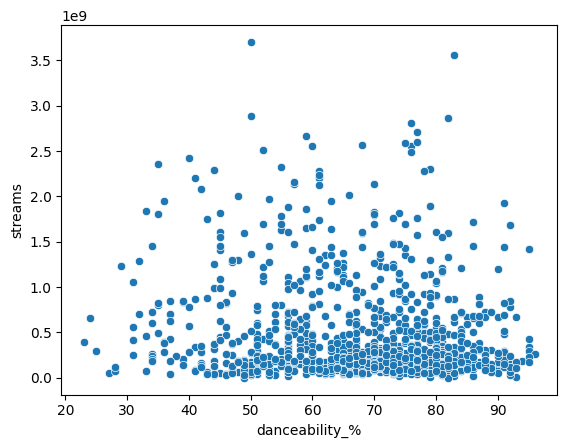

In [5]:
sns.scatterplot(data = df, x = "danceability_%", y = "streams")

## Streams per Artist

### Creating Artist Class with Payout Method

In [15]:
PAYOUT_RATE = 0.004

class Artist:

  def __init__(self, name, df):
    self.name = name
    self.df = df
    self.songs = df[df["artist(s)_name"].str.contains(name, case = False )]

  def payout(self, PAYOUT_RATE = 0.004 ):

    total_cash = 0

    for idx, song in self.songs.iterrows():

      song_streams = song["streams"]
      splits = song["artist_count"]

      valid_streams = song_streams / splits

      song_payout = valid_streams * PAYOUT_RATE
      total_cash += song_payout

    return total_cash



In [17]:
taylor = Artist("Taylor Swift", df)
taylor.payout()

57368072.96599999

##Winner and Loser(s)

In [ ]:
artist_streams = df.groupby(["artist(s)_name"])["streams"].sum()

### Function Graveyard

In [ ]:
"""
def show_songs(artist_name):

#First I store the entries for a specific artist in a df.

  all_songs = df[df["artist(s)_name"].str.contains(artist_name, case = False)]

#Then I filter which entries are collaborations.

  collabs = all_songs[all_songs["artist(s)_name"].str.contains(",")]

  if len(collabs) == 0:
     print(f"{artist_name} has {len(all_songs)} songs and no collaborations.")
  else:
     print(f"{artist_name} has {len(all_songs)} songs and is featured {len(collabs)} times.")

  print(df["splits"].value_counts())
"""

